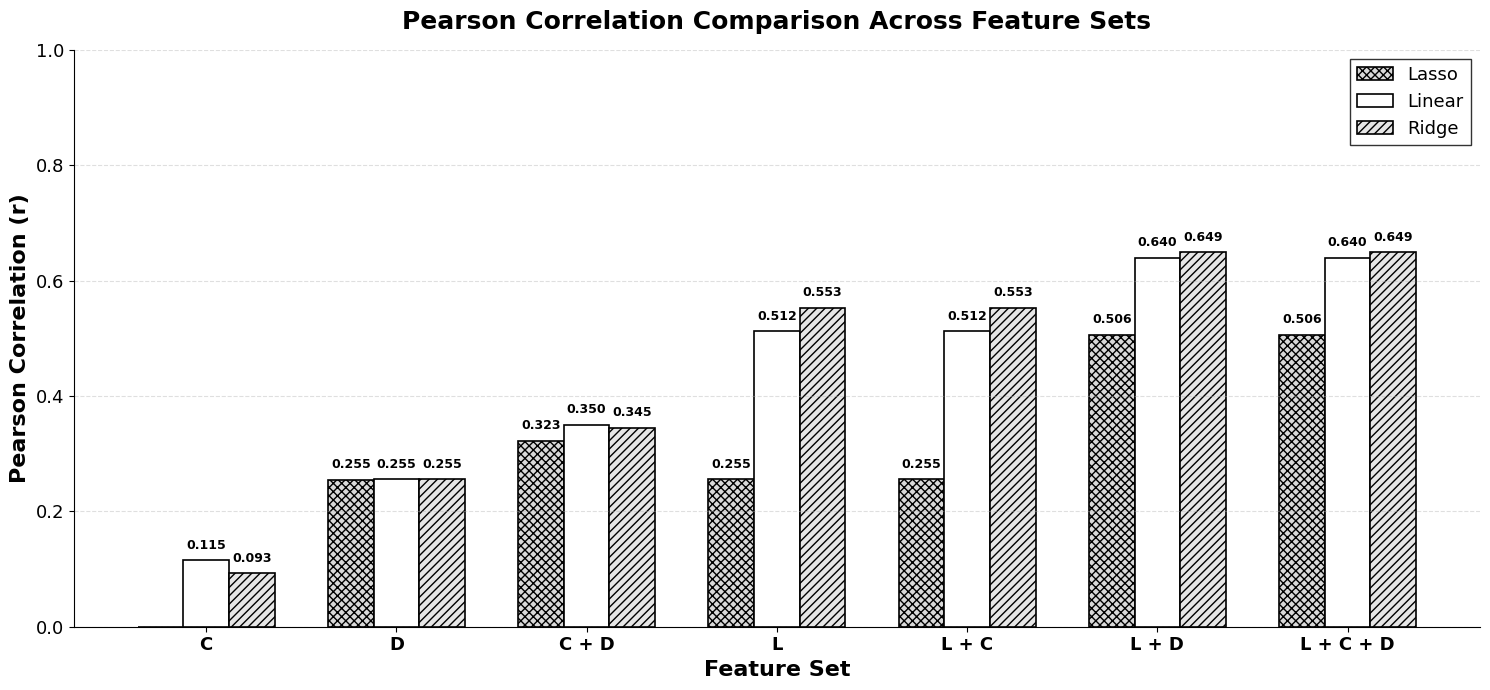

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_excel("../outputs/AHI.xlsx")

df["Model"] = df["Model"].ffill()

linear = df[df["Model"] == "Linear"]
ridge = df[df["Model"] == "Ridge"]
lasso = df[df["Model"] == "Lasso"]

feature_sets = linear["Feature Set"].tolist()

os.makedirs("../outputs/plots/comparison", exist_ok=True)

x = np.arange(len(feature_sets))
width = 0.24

fig, ax = plt.subplots(figsize=(15, 7))

bars1 = ax.bar(
    x - width,
    lasso["Pearson r"].clip(lower=0),
    width,
    label="Lasso",
    color="#D9D9D9",
    edgecolor="black",
    linewidth=1.2,
    hatch="xxxx"
)

bars2 = ax.bar(
    x,
    linear["Pearson r"],
    width,
    label="Linear",
    color="white",
    edgecolor="black",
    linewidth=1.2
)

bars3 = ax.bar(
    x + width,
    ridge["Pearson r"],
    width,
    label="Ridge",
    color="#E6E6E6",
    edgecolor="black",
    linewidth=1.2,
    hatch="////"
)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()

        if height <= 0:
            continue

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(
    feature_sets,
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Feature Set",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Pearson Correlation (r)",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "Pearson Correlation Comparison Across Feature Sets",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.tick_params(
    axis="y",
    labelsize=13
)

ax.set_ylim(0, 1)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.4
)

ax.legend(
    fontsize=13,
    frameon=True,
    edgecolor="black",
    fancybox=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/comparison/pearson_barplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

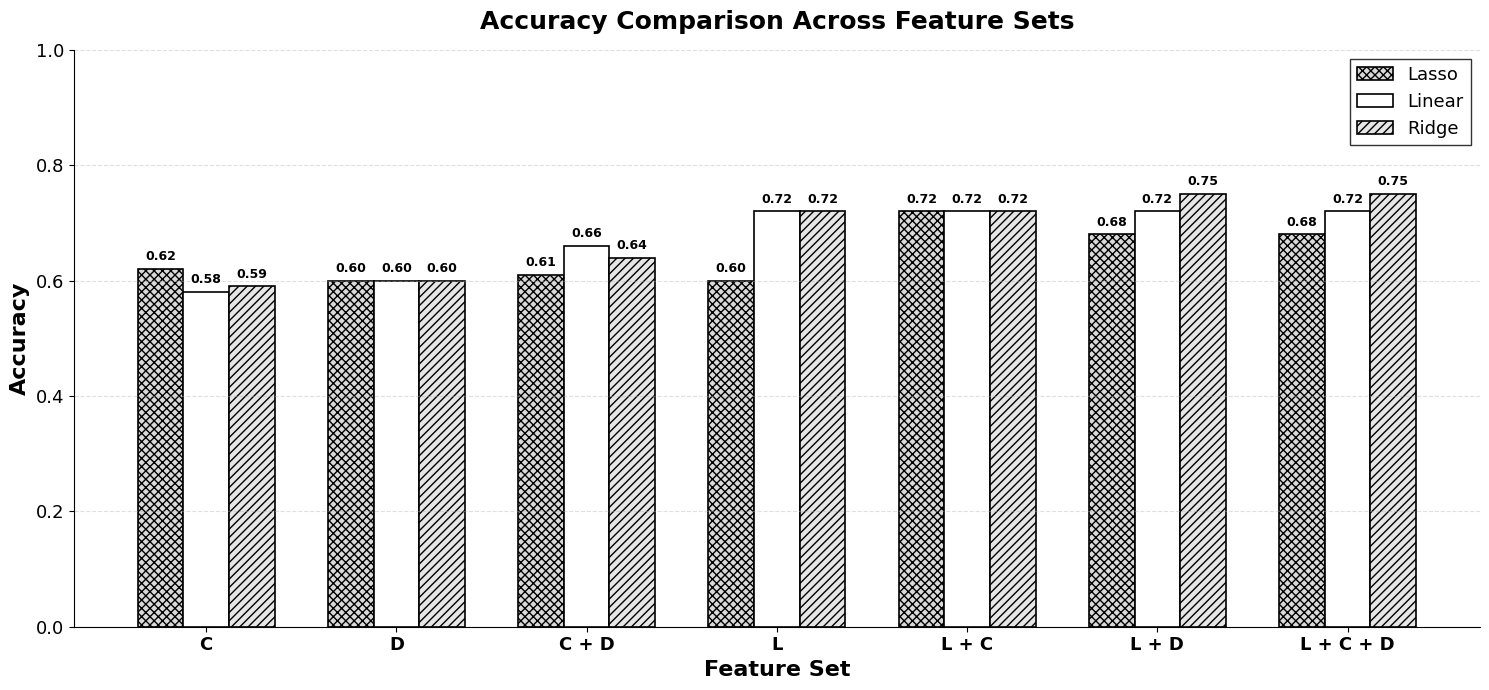

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_excel("../outputs/Severe.xlsx")

df["Model"] = df["Model"].ffill()

linear = df[df["Model"] == "Linear"]
ridge = df[df["Model"] == "Ridge"]
lasso = df[df["Model"] == "Lasso"]

feature_sets = linear["Feature Set"].tolist()

os.makedirs("../outputs/plots/comparison", exist_ok=True)

x = np.arange(len(feature_sets))
width = 0.24

fig, ax = plt.subplots(figsize=(15,7))

# Lasso (Left)
bars1 = ax.bar(
    x - width,
    lasso["Accuracy"],
    width,
    label="Lasso",
    color="#D9D9D9",
    edgecolor="black",
    linewidth=1.2,
    hatch="xxxx"
)

# Linear (Middle)
bars2 = ax.bar(
    x,
    linear["Accuracy"],
    width,
    label="Linear",
    color="white",
    edgecolor="black",
    linewidth=1.2
)

# Ridge (Right)
bars3 = ax.bar(
    x + width,
    ridge["Accuracy"],
    width,
    label="Ridge",
    color="#E6E6E6",
    edgecolor="black",
    linewidth=1.2,
    hatch="////"
)

for bars in [bars1, bars2, bars3]:
    for bar in bars:

        h = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(
    feature_sets,
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Feature Set",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Accuracy",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "Accuracy Comparison Across Feature Sets",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.tick_params(
    axis="y",
    labelsize=13
)

# Professor requested range
ax.set_ylim(0, 1)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.4
)

ax.legend(
    fontsize=13,
    frameon=True,
    edgecolor="black",
    fancybox=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/comparison/accuracy_barplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()